# 📊 E-Commerce Sales Data Analysis using Python & Pandas

## Project Overview

This project analyzes an e-commerce dataset using Python and Pandas to answer important business questions. The analysis focuses on customer behavior, sales trends, payment methods, product performance, and delivery performance.
The goal of this project is to demonstrate practical data analysis skills using real-world business data.

---

## Business Questions

- How has monthly revenue changed over time?
- Which states generate the highest revenue?
- Which product categories generate the most revenue?
- Which products are purchased most frequently?
- Which payment methods are most popular?
- How long does delivery usually take?
- Who are the highest spending customers?

---

## Tools & Libraries Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

---

## Dataset Used

The project uses the Brazilian E-Commerce Public Dataset.

Datasets used:

- customers.csv
- orders.csv
- order_items.csv
- order_payments.csv
- products.csv

# 1. Import Libraries

The first step is to import the Python libraries required for data analysis and visualization.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 2. Load the Datasets

This project uses five datasets from the Brazilian E-Commerce Public Dataset. Each dataset contains different business information.

| Dataset | Description |
|---------|-------------|
| customers.csv | Customer information |
| orders.csv | Order details |
| order_items.csv | Products included in each order |
| order_payments.csv | Payment information |
| products.csv | Product details |

These datasets will later be merged to answer business questions.

In [3]:
# Load all required datasets
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
payments = pd.read_csv('order_payments.csv')
products = pd.read_csv('products.csv')
order_items = pd.read_csv('order_items.csv')

# 3. Data Understanding

Before performing any analysis, it is important to understand the structure and contents of each dataset.

In this section, we examine:

- Sample records using `head()`
- Dataset dimensions using `shape`
- Data types using `info()`
- Summary statistics using `describe()`
- Missing values using `isnull().sum()`

Understanding the data helps us identify data quality issues and determine how the datasets should be merged for analysis.

## 3.1 Customers Dataset

### Business Purpose

The customers dataset contains information about each customer, including their unique identifier and location.

### One Row Represents

**One customer.**

### Analysis Performed

- View first five records
- Check dataset size
- Inspect data types
- Identify missing values

In [49]:
print("=" * 60)
print("CUSTOMERS DATASET")
print("=" * 60)

print("\n📌 First 5 Records")
display(customers.head())

print("\n📌 Dataset Shape")
print(customers.shape)

print("\n📌 Dataset Information")
customers.info()

print("\n📌 Summary Statistics")
display(customers.describe())

CUSTOMERS DATASET

📌 First 5 Records


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



📌 Dataset Shape
(99441, 5)

📌 Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

📌 Summary Statistics


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


## 3.2 Orders Dataset

### Business Purpose

The orders dataset stores information about every order placed by customers.

### One Row Represents

**One order.**

### Analysis Performed

- View first five records
- Check dataset size
- Inspect data types
- Identify missing values

In [50]:
print("=" * 60)
print("ORDERS DATASET")
print("=" * 60)

print("\n📌 First 5 Records")
display(orders.head())

print("\n📌 Dataset Shape")
print(orders.shape)

print("\n📌 Dataset Information")
orders.info()

print("\n📌 Summary Statistics")
display(orders.describe())

ORDERS DATASET

📌 First 5 Records


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02



📌 Dataset Shape
(99441, 9)

📌 Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
 8   month                          99441 non-null  period[M]     
dtypes: datetime64[ns](1), object(7), period[M](1)
memory usage: 6.8+ MB

📌 Summary Statistics


,order_purchase_timestamp
count,99441
mean,2017-12-31 08:43:12.776581120
min,2016-09-04 21:15:19
25%,2017-09-12 14:46:19
50%,2018-01-18 23:04:36
75%,2018-05-04 15:42:16
max,2018-10-17 17:30:18


## 3.3 Order Payments Dataset

### Business Purpose

This dataset contains payment details for each order, including payment type, number of installments, and payment amount.

### One Row Represents

**One payment transaction.**

### Analysis Performed

- View first five records
- Check dataset size
- Inspect data types
- Identify missing values

In [51]:
print("=" * 60)
print("ORDER PAYMENTS DATASET")
print("=" * 60)

print("\n📌 First 5 Records")
display(payments.head())

print("\n📌 Dataset Shape")
print(payments.shape)

print("\n📌 Dataset Information")
payments.info()

print("\n📌 Summary Statistics")
display(payments.describe())

ORDER PAYMENTS DATASET

📌 First 5 Records


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



📌 Dataset Shape
(103886, 5)

📌 Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

📌 Summary Statistics


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


## 3.4 Products Dataset

### Business Purpose

This dataset contains information about every product sold on the platform.

### One Row Represents

**One product.**

### Analysis Performed

- View first five records
- Check dataset size
- Inspect data types
- Identify missing values

In [52]:
print("=" * 60)
print("PRODUCTS DATASET")
print("=" * 60)

print("\n📌 First 5 Records")
display(products.head())

print("\n📌 Dataset Shape")
print(products.shape)

print("\n📌 Dataset Information")
products.info()

print("\n📌 Summary Statistics")
display(products.describe())

PRODUCTS DATASET

📌 First 5 Records


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



📌 Dataset Shape
(32951, 9)

📌 Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

📌 Summary Statistics


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


## 3.5 Order Items Dataset

### Business Purpose

The order items dataset links orders with the products that customers purchased.

### One Row Represents

**One product purchased in one order.**

### Analysis Performed

- View first five records
- Check dataset size
- Inspect data types
- Identify missing values

In [53]:
print("=" * 60)
print("ORDER ITEMS DATASET")
print("=" * 60)

print("\n📌 First 5 Records")
display(order_items.head())

print("\n📌 Dataset Shape")
print(order_items.shape)

print("\n📌 Dataset Information")
order_items.info()

print("\n📌 Summary Statistics")
display(order_items.describe())

ORDER ITEMS DATASET

📌 First 5 Records


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



📌 Dataset Shape
(112650, 7)

📌 Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

📌 Summary Statistics


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


# 4. Data Cleaning

Before analyzing the data, it is important to clean and prepare it.

In this section, we:

- Check missing values
- Convert date columns to datetime format
- Create a new month column for monthly analysis

Proper data cleaning ensures that our analysis is accurate and reliable.

## 4.1 Missing Values Analysis

Missing values are common in real-world datasets.

Before performing any analysis, we identify columns containing missing values to understand whether data cleaning or special handling is required.

In our dataset, only the Orders dataset contains missing values, mainly because some orders were cancelled or not yet delivered.

In [15]:
print("=" * 60)
print("MISSING VALUES SUMMARY")
print("=" * 60)

print("\nCustomers")
print(customers.isnull().sum())

print("\nOrders")
print(orders.isnull().sum())

print("\nPayments")
print(payments.isnull().sum())

print("\nProducts")
print(products.isnull().sum())

print("\nOrder Items")
print(order_items.isnull().sum())

MISSING VALUES SUMMARY

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: in

### Observation

Most missing values occur in delivery-related columns.

For example:

- `order_delivered_customer_date`
- `order_delivered_carrier_date`

These values are expected to be missing for cancelled or undelivered orders.

Since these missing values represent real business situations rather than data errors, they were not removed.

## 4.2 Convert Date Columns

The order purchase date is stored as text (object datatype).

To perform time-based analysis such as monthly revenue trends and delivery time calculations, it must be converted into a datetime format.

In [54]:
# Convert purchase date from object to datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

### Why Convert to Datetime?

Datetime columns allow us to perform date-based analysis, such as:

- Monthly sales trends
- Yearly trends
- Delivery duration
- Weekday analysis

Without converting to datetime, these operations would not be possible.

## 4.3 Create Month Column

To analyze monthly business performance, a new column called **month** is created from the order purchase date.

This allows us to group orders by month and calculate metrics such as revenue and number of orders.

In [55]:
# Create a month column for monthly trend analysis
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders[['order_purchase_timestamp', 'month']].head()

,order_purchase_timestamp,month
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


### Why Use `.dt.to_period('M')`?

The `month` column stores only the year and month (for example, `2018-01`) instead of the full date.

This makes grouping data by month much easier.

Example:

| Purchase Date | Month |
|---------------|--------|
| 2018-01-15 | 2018-01 |
| 2018-01-28 | 2018-01 |
| 2018-02-03 | 2018-02 |

## Data Cleaning Summary

The following preprocessing steps were completed:

- Checked for missing values
- Identified that missing values mainly represent cancelled or undelivered orders
- Converted purchase date to datetime format
- Created a month column for time-based analysis

The dataset is now ready for merging and exploratory data analysis.

# 5. Data Preparation & Merging

The information required for business analysis is distributed across multiple datasets.

To answer business questions, these datasets need to be combined using common keys such as:

- customer_id
- order_id
- product_id

Merging datasets creates a single dataset that contains all the information required for analysis.

## 5.1 Merge Customers and Orders

### Business Question

Which customer placed each order?

The **customers** dataset contains customer information, while the **orders** dataset contains order information.

Both datasets share a common column:

**customer_id**

Using this key, we combine customer information with every order.

In [21]:
# Merge customer and order information using customer_id
customer_orders = pd.merge(customers,orders,on='customer_id')
customer_orders.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,2018-07


### One Row Represents

After merging:

**One customer's information together with one order placed by that customer.**

In [22]:
print("Shape:", customer_orders.shape)

customer_orders.info()

Shape: (99441, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   customer_id                    99441 non-null  object        
 1   customer_unique_id             99441 non-null  object        
 2   customer_zip_code_prefix       99441 non-null  int64         
 3   customer_city                  99441 non-null  object        
 4   customer_state                 99441 non-null  object        
 5   order_id                       99441 non-null  object        
 6   order_status                   99441 non-null  object        
 7   order_purchase_timestamp       99441 non-null  datetime64[ns]
 8   order_approved_at              99281 non-null  object        
 9   order_delivered_carrier_date   97658 non-null  object        
 10  order_delivered_customer_date  96476 non-null  object        
 

### Observation

The merge was successful because every order belongs to exactly one customer.

The merged dataset now contains customer details together with order information, making customer-level analysis possible.

## 5.2 Merge Payment Information

### Business Question

How much did each customer pay for each order?

The payment dataset is merged using the common column:

**order_id**

This adds payment information to every order.

In [23]:
# Add payment details to customer orders
final_data = pd.merge(customer_orders,payments,on='order_id')
final_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,2017-05,1,credit_card,2,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,2018-01,1,credit_card,8,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,2018-05,1,credit_card,7,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,2018-03,1,credit_card,1,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,2018-07,1,credit_card,8,252.25


### One Row Represents

After this merge:

**One payment transaction together with customer information and order details.**

In [24]:
print("Shape:", final_data.shape)
final_data.info()

Shape: (103886, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    103886 non-null  object        
 1   customer_unique_id             103886 non-null  object        
 2   customer_zip_code_prefix       103886 non-null  int64         
 3   customer_city                  103886 non-null  object        
 4   customer_state                 103886 non-null  object        
 5   order_id                       103886 non-null  object        
 6   order_status                   103886 non-null  object        
 7   order_purchase_timestamp       103886 non-null  datetime64[ns]
 8   order_approved_at              103711 non-null  object        
 9   order_delivered_carrier_date   101998 non-null  object        
 10  order_delivered_customer_date  100754 non-null  

### Observation

The number of rows increased after this merge.

This is because one order can have multiple payment records.

For example, a customer may split the payment into multiple installments or payment entries.

Therefore, one order may appear multiple times after the merge.

## 5.3 Merge Orders and Order Items

### Business Question

Which products were included in each order?

The order_items dataset contains product information for every order.

The datasets are merged using:

**order_id**

In [25]:
orders_items = pd.merge(orders,order_items,on='order_id')
orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


### One Row Represents

One product purchased within one order.

In [26]:
print("Shape:", orders_items.shape)
orders_items.info()

Shape: (112650, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   customer_id                    112650 non-null  object        
 2   order_status                   112650 non-null  object        
 3   order_purchase_timestamp       112650 non-null  datetime64[ns]
 4   order_approved_at              112635 non-null  object        
 5   order_delivered_carrier_date   111456 non-null  object        
 6   order_delivered_customer_date  110196 non-null  object        
 7   order_estimated_delivery_date  112650 non-null  object        
 8   month                          112650 non-null  period[M]     
 9   order_item_id                  112650 non-null  int64         
 10  product_id                     112650 non-null  

## 5.4 Merge Product Information

### Business Question

What product category was purchased in each order?

The products dataset contains information about every product.

The datasets are merged using:

**product_id**

In [27]:
final_products = pd.merge(orders_items,products,on='product_id')
final_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,order_item_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,1,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,1,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,1,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,1,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,1,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


### One Row Represents

One purchased product together with its product information.

## Data Preparation Summary

Four datasets were created during the data preparation process.

| Dataset | One Row Represents |
|---------|--------------------|
| customer_orders | One customer together with one order |
| final_data | One payment transaction together with customer and order information |
| orders_items | One product purchased in one order |
| final_products | One purchased product together with product information |

These merged datasets will be used throughout the Exploratory Data Analysis (EDA) section.

# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to answer key business questions using the prepared datasets.

Each analysis includes:

- Business Question
- Analysis Approach
- Results
- Visualization
- Business Insight

The objective is to convert raw data into meaningful business decisions.

## 6.1 Monthly Revenue Trend

### Business Question

How has the company's revenue changed over time?

### Approach

Group orders by month and calculate the total payment received in each month.

In [28]:
# Calculate total revenue for each month
monthly_revenue = final_data.groupby('month')['payment_value'].sum()
monthly_revenue

month
2016-09        252.24
2016-10      59090.48
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194882.80
2017-12     878401.48
2018-01    1115004.18
2018-02     992463.34
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

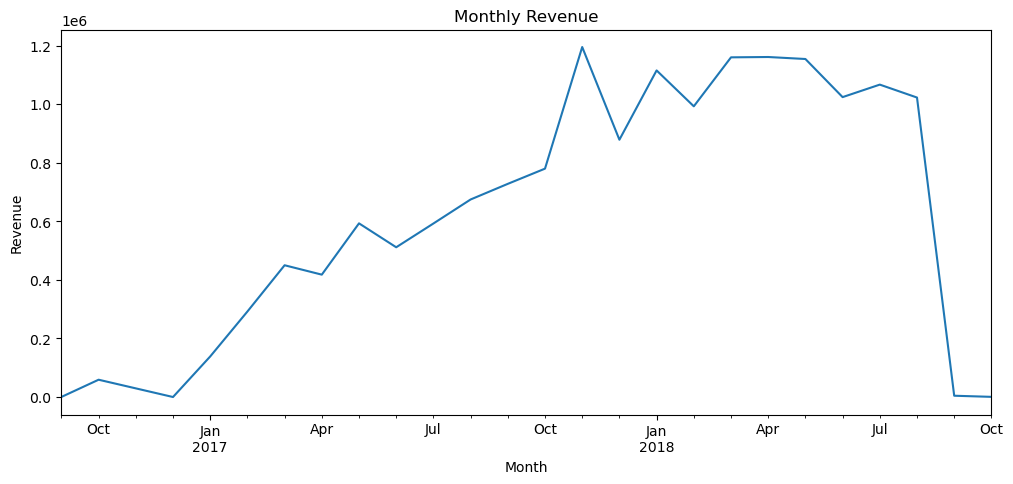

In [29]:
monthly_revenue.plot(figsize=(12,5), title='Monthly Revenue')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### Business Insight

- Revenue increased steadily during 2017.
- November 2017 recorded the highest monthly revenue.
- The sharp decline in the final months occurs because the dataset contains only a few records for those months.

## 6.2 Monthly Order Trend

### Business Question

How many orders were placed each month?

### Approach

Group orders by month and count the number of orders.

In [30]:
monthly_orders = orders.groupby('month')['order_id'].count()
monthly_orders

month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

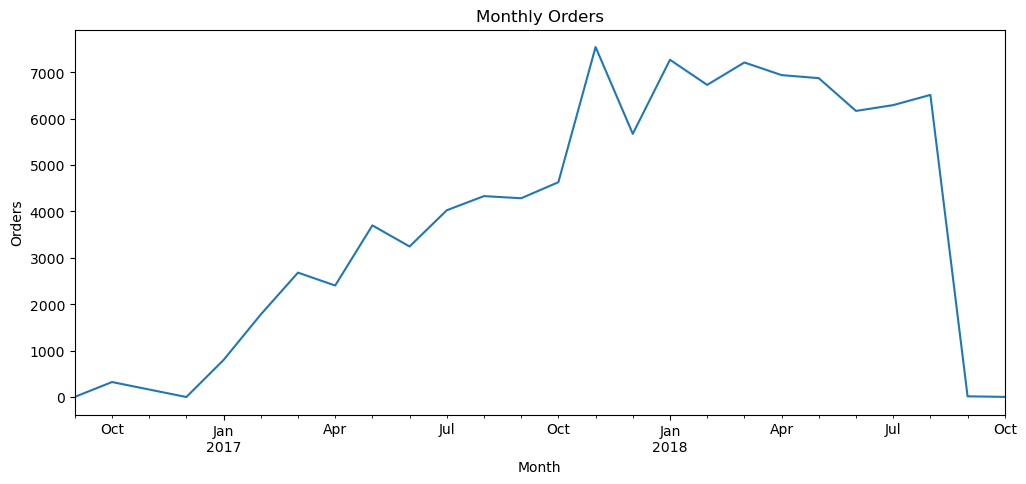

In [31]:
monthly_orders.plot(figsize=(12,5), title='Monthly Orders')
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

### Business Insight

- The number of orders increased throughout 2017.
- Monthly order trends closely follow monthly revenue trends.

## 6.3 Average Order Value (AOV)

### Business Question

How much does a customer spend on average per order?

### Approach

Average Order Value is calculated as:

**Revenue ÷ Number of Orders**

In [32]:
monthly_aov = monthly_revenue / monthly_orders
monthly_aov

month
2016-09     63.060000
2016-10    182.378025
2016-12     19.620000
2017-01    173.110050
2017-02    163.993264
2017-03    167.734377
2017-04    173.788698
2017-05    160.248330
2017-06    157.558206
2017-07    147.139324
2017-08    155.713766
2017-09    169.839545
2017-10    168.360587
2017-11    158.388494
2017-12    154.838971
2018-01    153.391688
2018-02    147.512387
2018-03    160.817102
2018-04    167.284260
2018-05    167.900793
2018-06    166.025701
2018-07    169.507430
2018-08    157.006345
2018-09    277.471250
2018-10    147.417500
Freq: M, dtype: float64

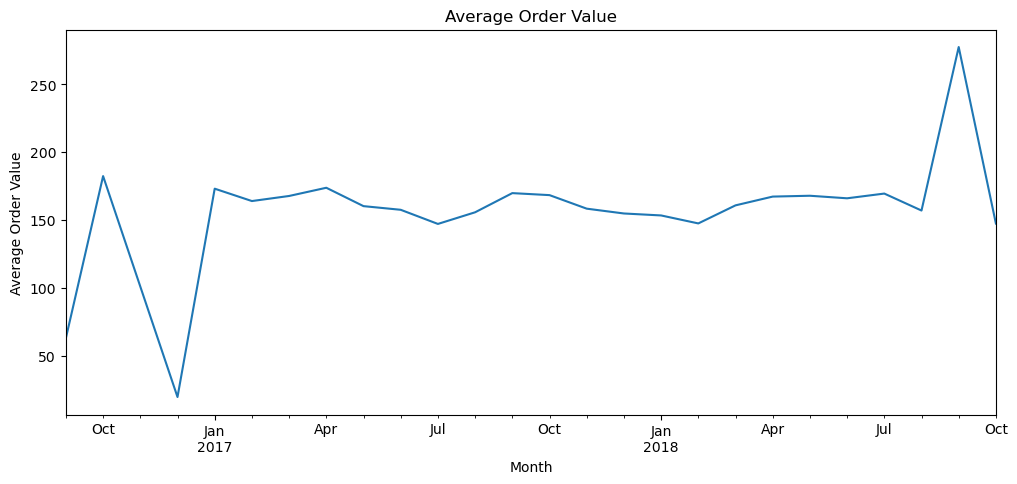

In [33]:
monthly_aov.plot(figsize=(12,5), title='Average Order Value')
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.show()

### Business Insight

Although the number of orders increased over time, the average order value remained relatively stable, indicating consistent customer spending.

## 6.4 Revenue by State

### Business Question

Which states generate the highest revenue?

In [34]:
# Calculate total revenue generated by each state
state_revenue = final_data.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)
state_revenue.head(10)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: payment_value, dtype: float64

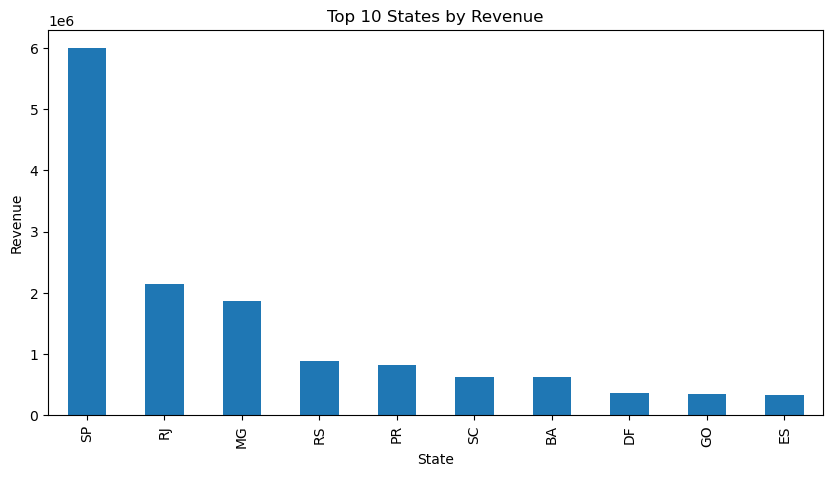

In [35]:
state_revenue.head(10).plot(kind='bar', figsize=(10,5), title='Top 10 States by Revenue')
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()

### Business Insight

São Paulo (SP) generated the highest revenue, making it the company's strongest market.

## 6.5 Payment Method Analysis

### Business Question

Which payment methods are most frequently used, and which generate the highest revenue?

In [36]:
payment_count = final_data['payment_type'].value_counts()
payment_count

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

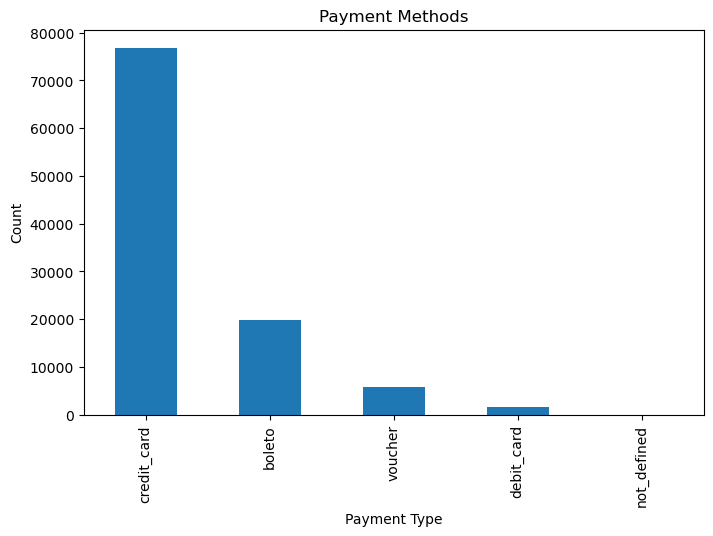

In [37]:
payment_count.plot(kind='bar', figsize=(8,5), title='Payment Methods')
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

In [38]:
payment_revenue = final_data.groupby('payment_type')['payment_value'].sum()
payment_revenue

payment_type
boleto          2869361.27
credit_card    12542084.19
debit_card       217989.79
not_defined           0.00
voucher          379436.87
Name: payment_value, dtype: float64

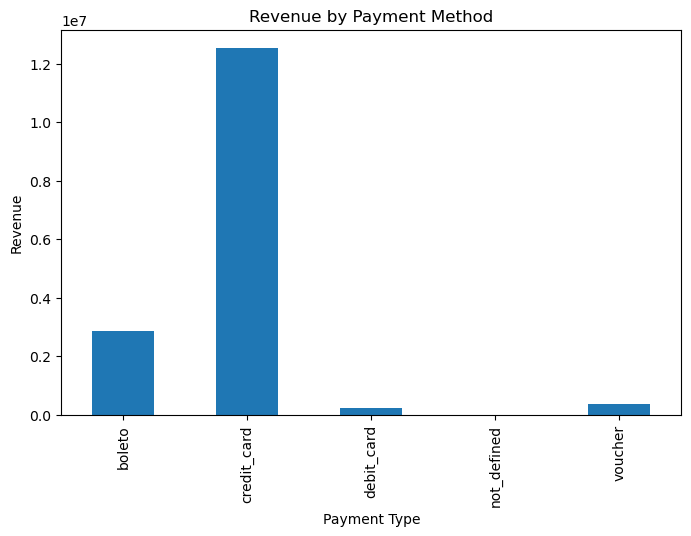

In [39]:
payment_revenue.plot(kind='bar', figsize=(8,5), title='Revenue by Payment Method')
plt.xlabel("Payment Type")
plt.ylabel("Revenue")
plt.show()

### Business Insight

Credit cards are the most frequently used payment method and generate the highest revenue.

## 6.6 Product Category Revenue

### Business Question

Which product categories generate the highest revenue?

In [40]:
# Calculate revenue generated by each product category
product_revenue = final_products.groupby('product_category_name')['price'].sum().sort_values(ascending=False)
product_revenue.head(10)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

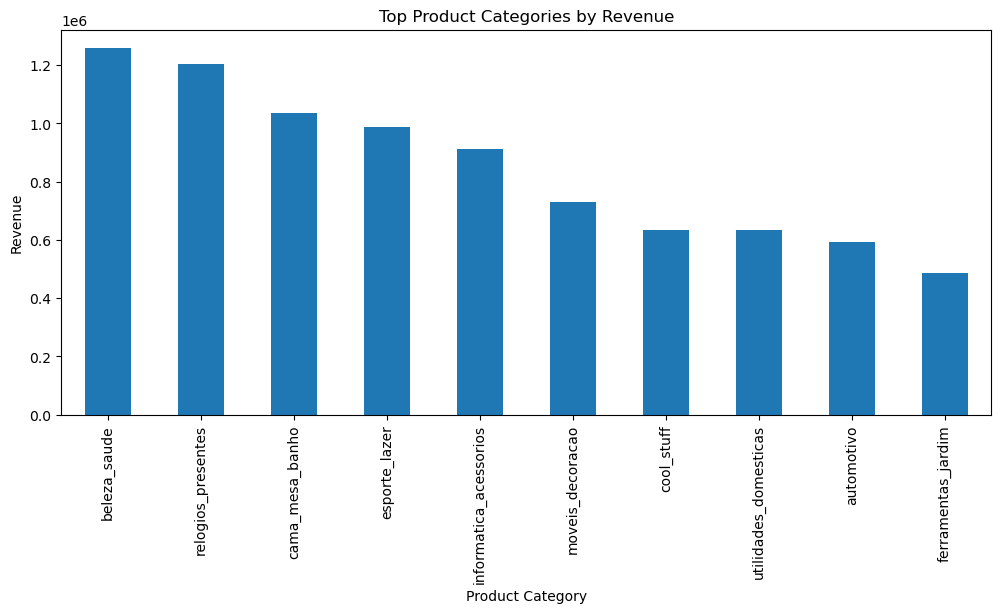

In [41]:
product_revenue.head(10).plot(kind='bar', figsize=(12,5), title='Top Product Categories by Revenue')
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

### Business Insight

Beauty & Health products generated the highest revenue, followed by Watches & Gifts.

## 6.7 Product Sales Count

### Business Question

Which products are purchased most frequently?

In [42]:
product_count = final_products['product_category_name'].value_counts()
product_count.head(10)

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64

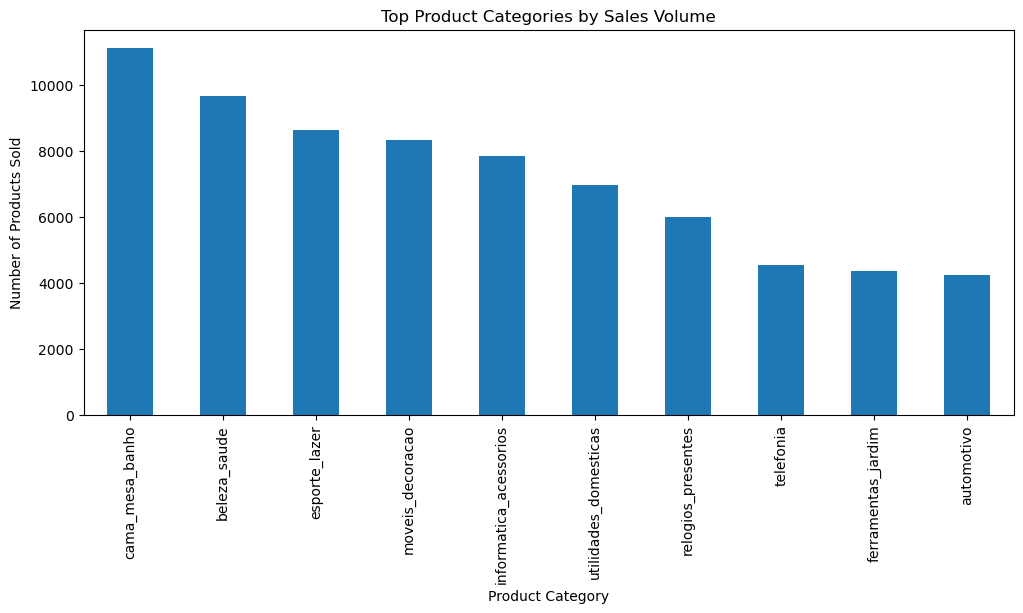

In [43]:
product_count.head(10).plot(kind='bar', figsize=(12,5), title='Top Product Categories by Sales Volume')
plt.xlabel("Product Category")
plt.ylabel("Number of Products Sold")
plt.show()

### Business Insight

Bed, Table & Bath products were sold most frequently, showing strong customer demand.

## 6.8 Delivery Performance

### Business Question

How long does it take for customers to receive their orders?

In [44]:
# Calculate the number of days taken to deliver each order
final_data['delivery_days'] = (pd.to_datetime(final_data['order_delivered_customer_date'])- final_data['order_purchase_timestamp']).dt.days
final_data['delivery_days'].describe()

count    100754.000000
mean         12.106348
std           9.555269
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

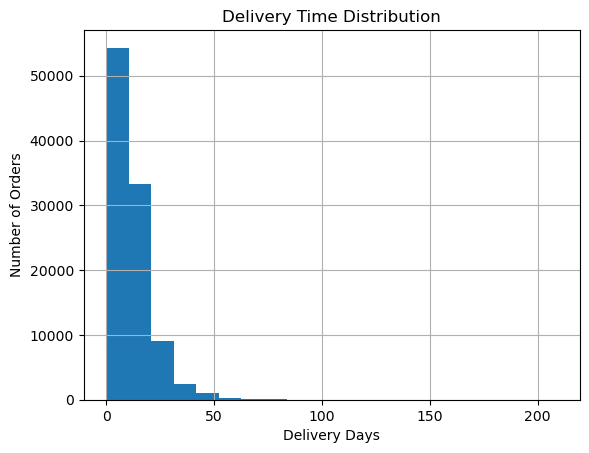

In [45]:
final_data['delivery_days'].hist(bins=20)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

### Business Insight

- Average delivery time is approximately 12 days.
- Most deliveries are completed within 10–15 days.
- A small number of orders experienced significantly longer delivery times.

## 6.9 Top Customers

### Business Question

Who are the highest spending customers?

In [46]:
top_customers = final_data.groupby('customer_unique_id')['payment_value'].sum().sort_values(ascending=False)
top_customers.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: payment_value, dtype: float64

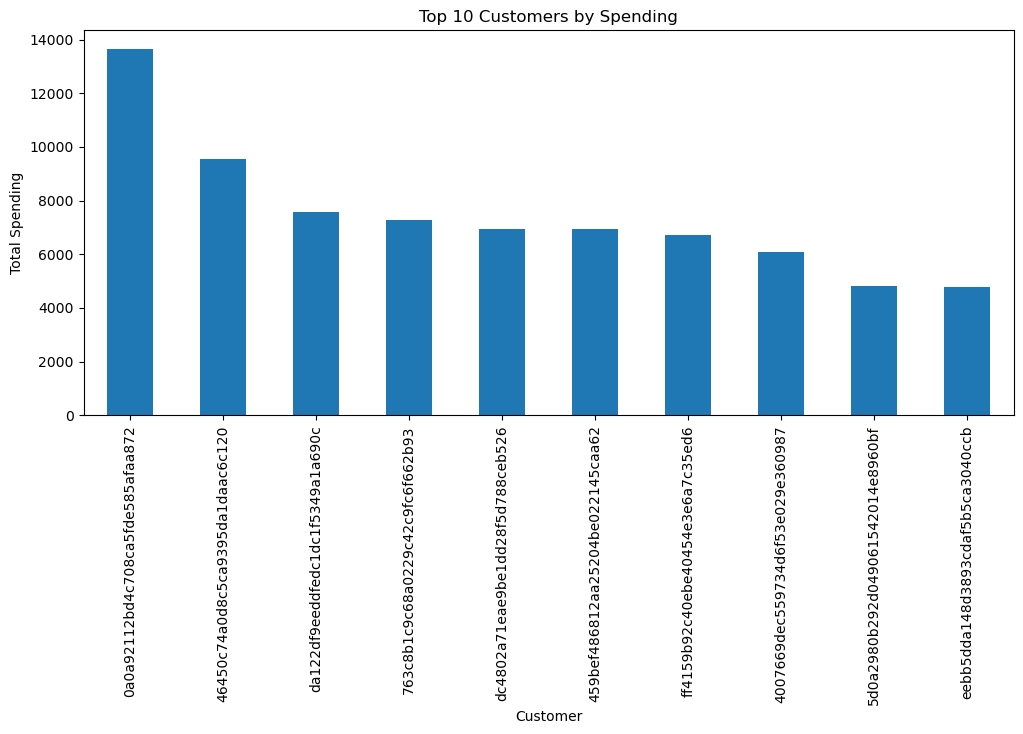

In [47]:
top_customers.head(10).plot(kind='bar', figsize=(12,5), title='Top 10 Customers by Spending')
plt.xlabel("Customer")
plt.ylabel("Total Spending")
plt.show()

### Business Insight

The company has a small group of high-value customers who contribute significantly to total revenue. These customers could be targeted with loyalty programs and personalized offers.

# 7. Business Insights Summary

Based on the exploratory data analysis, the following key business insights were identified.

## Key Findings

### 1. Revenue Growth

- Revenue increased consistently throughout 2017.
- November 2017 recorded the highest monthly revenue.
- The decline at the end of the dataset is due to incomplete monthly data.

---

### 2. Customer Demand

- The number of monthly orders increased steadily.
- Customer purchasing activity grew over time.

---

### 3. Geographic Performance

- São Paulo (SP) generated the highest revenue.
- Rio de Janeiro (RJ) and Minas Gerais (MG) were the next strongest markets.

---

### 4. Product Performance

- Beauty & Health generated the highest revenue.
- Bed, Table & Bath products were purchased most frequently.

---

### 5. Payment Behaviour

- Credit cards were the preferred payment method.
- They also generated the highest revenue.

---

### 6. Delivery Performance

- Average delivery time was approximately 12 days.
- Most deliveries were completed within 10–15 days.

---

### 7. Customer Spending

- A small group of customers contributed a large portion of total revenue.
- These customers represent an opportunity for loyalty and retention programs.

# 8. Business Recommendations

Based on the analysis, the following recommendations can help improve business performance.

## Recommendation 1

Increase marketing investment in São Paulo, Rio de Janeiro and Minas Gerais because these states generate the highest revenue.

---

## Recommendation 2

Promote Beauty & Health and Watches & Gifts products since they contribute significantly to revenue.

---

## Recommendation 3

Maintain strong inventory levels for Bed, Table & Bath products because of their high sales volume.

---

## Recommendation 4

Reward high-value customers through loyalty programs, discounts or exclusive offers.

---

## Recommendation 5

Investigate unusually long delivery times to improve customer satisfaction.

# 9. Skills Demonstrated

This project demonstrates the following technical skills:

### Python

- Variables
- Functions
- Data Structures

### Pandas

- read_csv()
- head()
- shape
- info()
- describe()
- isnull()
- value_counts()
- groupby()
- sum()
- mean()
- sort_values()
- merge()
- to_datetime()
- dt accessor
- to_period()

### Data Analysis

- Data Cleaning
- Data Preparation
- Data Merging
- Exploratory Data Analysis (EDA)
- Business Insights

### Data Visualization

- Line Charts
- Bar Charts
- Histograms

### Business Understanding

- Revenue Analysis
- Customer Analysis
- Product Analysis
- Payment Analysis
- Delivery Analysis

# 10. Conclusion

This project analyzed a real-world e-commerce dataset using Python and Pandas.

The analysis covered:

- Customer behaviour
- Revenue trends
- Product performance
- Payment methods
- Delivery performance

Multiple datasets were cleaned, merged and analyzed to answer key business questions.

The project demonstrates practical data analysis skills including data preparation, exploratory data analysis, visualization and business insight generation.

This project serves as a portfolio example for Data Analyst, SQL Developer and Junior Data Engineer roles.

# 11. Future Improvements

Future enhancements for this project include:

- Build an interactive Power BI dashboard.
- Perform SQL-based analysis on the same dataset.
- Create customer segmentation using RFM analysis.
- Predict customer lifetime value using machine learning.
- Forecast future sales using time-series analysis.